# Distribuição, assimetria, curtose e síntese

Esta seção examina a distribuição municipal do PIB, da população e do PIB per capita
no Sudeste em 2020. O objetivo é complementar as análises anteriores com boxplots,
assimetria e curtose e, ao final, sintetizar as evidências e limitações do trabalho.

O recorte contém Espírito Santo, Minas Gerais, Rio de Janeiro e São Paulo. PIB per
capita representa produção econômica por habitante, não renda individual.

## 1. Bibliotecas, caminhos e carga da base

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis
from IPython.display import display

ds_root = next(
    (p for p in [Path.cwd(), *Path.cwd().parents]
     if (p / 'data/processed/sudeste_municipios.parquet').exists()),
    None,
)
if ds_root is None:
    raise FileNotFoundError('Base tratada não encontrada a partir do diretório atual.')

ds_df = pd.read_parquet(ds_root / 'data/processed/sudeste_municipios.parquet')
ds_fig_dir = ds_root / 'outputs/figures'
ds_out_dir = ds_root / 'outputs/distribuicao_sintese'
ds_fig_dir.mkdir(parents=True, exist_ok=True)
ds_out_dir.mkdir(parents=True, exist_ok=True)

ds_variaveis = ['pib_total_reais', 'populacao', 'pib_per_capita_reais']
ds_rotulos = ['PIB total (R$)', 'População (pessoas)', 'PIB per capita (R$)']
ds_ufs = {'ES', 'MG', 'RJ', 'SP'}

assert set(ds_df['uf'].dropna().unique()) == ds_ufs
assert ds_df[['codigo_municipio', 'ano']].duplicated().sum() == 0
assert not ds_df[ds_variaveis].isna().any().any()
assert (ds_df[ds_variaveis] > 0).all().all()
print(f'Base validada: {len(ds_df):,} municípios; ano {int(ds_df.ano.min())}.')

Base validada: 1,668 municípios; ano 2020.


## 2. Assimetria e curtose

A assimetria indica o grau de falta de simetria. Valores positivos mostram cauda à
direita. A curtose de Fisher usa zero como referência da distribuição normal;
valores positivos indicam caudas mais pesadas. As métricas são apresentadas na
escala original e após transformação $\log_{10}$.

In [2]:
ds_resultados = []
for ds_coluna, ds_rotulo in zip(ds_variaveis, ds_rotulos):
    ds_original = ds_df[ds_coluna].astype(float)
    ds_log = np.log10(ds_original)
    ds_resultados.append({
        'variavel': ds_rotulo,
        'n': len(ds_original),
        'assimetria_original': skew(ds_original, bias=False),
        'curtose_fisher_original': kurtosis(ds_original, fisher=True, bias=False),
        'assimetria_log10': skew(ds_log, bias=False),
        'curtose_fisher_log10': kurtosis(ds_log, fisher=True, bias=False),
    })

ds_metricas = pd.DataFrame(ds_resultados)
ds_metricas.to_csv(ds_out_dir / 'metricas_distribuicao.csv', index=False)
display(ds_metricas.round(3))

,variavel,n,assimetria_original,curtose_fisher_original,assimetria_log10,curtose_fisher_log10
0,PIB total (R$),1668,30.160,1026.784,0.865,0.497
1,População (pessoas),1668,27.420,859.998,0.928,1.035
2,PIB per capita (R$),1668,5.421,40.751,0.865,1.417


### Interpretação

Na escala original, as três variáveis apresentam assimetria positiva e curtose de
Fisher elevada, compatíveis com muitos municípios de valores menores e poucos
valores extremos. A transformação logarítmica reduz fortemente essas medidas, mas
não torna as distribuições simétricas: as assimetrias em log permanecem positivas,
entre aproximadamente 0,86 e 0,93. O log melhora a visualização de ordens de
grandeza diferentes, sem eliminar a heterogeneidade dos dados.

## 3. Boxplots das variáveis municipais

/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_7801/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_7801/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
/var/folders/t4/v1l3095d3w3fm_txfp16v38r0000gn/T/ipykernel_7801/1706060746.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,


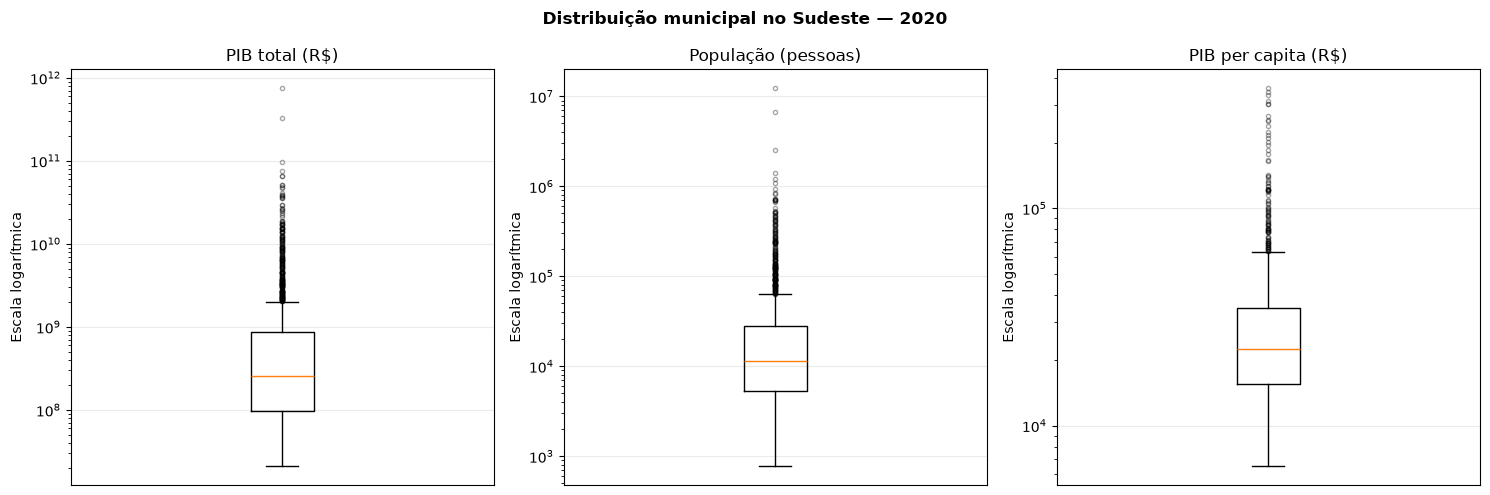

In [3]:
ds_fig, ds_axes = plt.subplots(1, 3, figsize=(15, 5))
for ds_ax, ds_coluna, ds_rotulo in zip(ds_axes, ds_variaveis, ds_rotulos):
    ds_ax.boxplot(ds_df[ds_coluna], vert=True, showfliers=True,
                  flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35})
    ds_ax.set_yscale('log')
    ds_ax.set_title(ds_rotulo)
    ds_ax.set_ylabel('Escala logarítmica')
    ds_ax.set_xticks([])
    ds_ax.grid(axis='y', alpha=0.25)

ds_fig.suptitle('Distribuição municipal no Sudeste — 2020', fontweight='bold')
ds_fig.tight_layout()
ds_fig.savefig(ds_fig_dir / 'boxplots_distribuicao.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. PIB per capita por estado

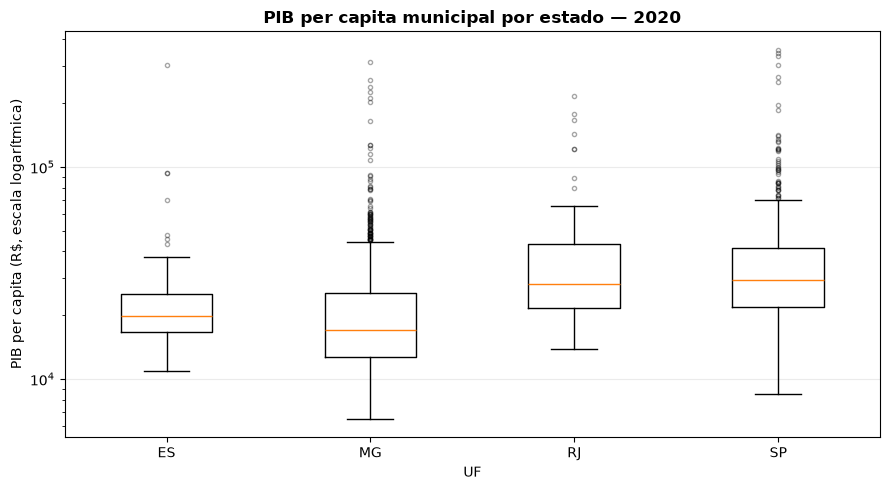

,uf,mediana_pib_per_capita_reais
3,SP,"R$ 29,433.12"
2,RJ,"R$ 28,095.57"
0,ES,"R$ 19,770.69"
1,MG,"R$ 16,968.02"


In [4]:
ds_ordem_uf = ['ES', 'MG', 'RJ', 'SP']
ds_grupos = [
    ds_df.loc[ds_df['uf'].eq(ds_uf), 'pib_per_capita_reais'].to_numpy()
    for ds_uf in ds_ordem_uf
]
ds_fig, ds_ax = plt.subplots(figsize=(9, 5))
ds_ax.boxplot(ds_grupos, tick_labels=ds_ordem_uf, showfliers=True,
              flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.35})
ds_ax.set_yscale('log')
ds_ax.set_title('PIB per capita municipal por estado — 2020', fontweight='bold')
ds_ax.set_xlabel('UF')
ds_ax.set_ylabel('PIB per capita (R$, escala logarítmica)')
ds_ax.grid(axis='y', alpha=0.25)
ds_fig.tight_layout()
ds_fig.savefig(ds_fig_dir / 'boxplot_pib_per_capita_por_uf.png', dpi=180,
               bbox_inches='tight')
plt.show()

ds_mediana_uf = (
    ds_df.groupby('uf', as_index=False)['pib_per_capita_reais']
    .median()
    .rename(columns={'pib_per_capita_reais': 'mediana_pib_per_capita_reais'})
    .sort_values('mediana_pib_per_capita_reais', ascending=False)
)
display(ds_mediana_uf.style.format({'mediana_pib_per_capita_reais': 'R$ {:,.2f}'}))

Os quatro estados apresentam valores extremos superiores e dispersão interna. São
Paulo possui a maior mediana municipal de PIB per capita no recorte, seguido por
Rio de Janeiro, Espírito Santo e Minas Gerais. Isso descreve as distribuições dos
municípios e não equivale à renda mediana de seus habitantes.

## 5. Síntese das evidências

In [5]:
ds_media_pc = ds_df['pib_per_capita_reais'].mean()
ds_mediana_pc = ds_df['pib_per_capita_reais'].median()
ds_corr_log = np.corrcoef(
    np.log10(ds_df['populacao']), np.log10(ds_df['pib_total_reais'])
)[0, 1]
ds_va = [
    'va_agropecuaria_reais', 'va_industria_reais',
    'va_servicos_reais', 'va_administracao_publica_reais',
]
ds_setor_maior = ds_df[ds_va].sum().idxmax().replace('va_', '').replace('_reais', '')

ds_sintese = pd.DataFrame({
    'indicador': [
        'Municípios analisados', 'Média municipal do PIB per capita',
        'Mediana municipal do PIB per capita',
        'Correlação de Pearson entre log10 população e log10 PIB',
        'Setor com maior VA agregado no Sudeste',
    ],
    'resultado': [
        f'{len(ds_df):,}', f'R$ {ds_media_pc:,.2f}', f'R$ {ds_mediana_pc:,.2f}',
        f'{ds_corr_log:.3f}', ds_setor_maior.title(),
    ],
})
display(ds_sintese)

,indicador,resultado
0,Municípios analisados,"1,668"
1,Média municipal do PIB per capita,"R$ 30,364.89"
2,Mediana municipal do PIB per capita,"R$ 22,531.00"
3,Correlação de Pearson entre log10 população e ...,0.933
4,Setor com maior VA agregado no Sudeste,Servicos


## 6. Conclusão geral e limitações

Os resultados sustentam que há desigualdades econômicas relevantes **entre os
municípios do Sudeste em 2020**. A média municipal do PIB per capita supera a
mediana, as distribuições possuem cauda longa à direita e os boxplots exibem muitos
valores extremos. O PIB e a população estão fortemente associados em escala
logarítmica, enquanto a composição econômica e a produção por habitante variam
entre os estados e dentro deles. Em conjunto, essas evidências mostram concentração
territorial de população e atividade econômica no recorte estudado.

Contudo, a pergunta “O Brasil é um país desigual?” é mais ampla do que esta base
permite responder. O estudo cobre somente o Sudeste e um único ano; PIB per capita
não mede renda pessoal, distribuição de renda, pobreza ou qualidade de vida. O
resultado também pode ser influenciado por municípios industriais ou petrolíferos
com população residente pequena e por deslocamentos pendulares de trabalhadores.
Uma conclusão nacional exigiria incluir as demais regiões, outros anos e indicadores
sociais como renda domiciliar, pobreza e índice de Gini.

**Fontes:** PIB dos Municípios, Estimativas da População e Divisão Territorial
Brasileira, do IBGE, conforme os arquivos originais e metadados documentados na
etapa de preparação dos dados deste projeto.